# MOHAMED EL-GHALI GLCC

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [79]:
# Fonction de normalisation classique (Z-score)
def normalize(X):
    m_mean = X.mean(axis=0)
    m_std = X.std(axis=0)
    return (X - m_mean) / m_std

In [80]:
# Chargement et préparation des données
data=pd.read_csv("../datasets/gold-monthly.csv")
# Astuce : on transforme les dates (ex: "2023-01") en entiers continus pour que le modèle puisse les utiliser
X_int = data["Date"].str.replace("-", "").astype(int).values
X=normalize(X_int)
Y=normalize(data[["Price"]].values)

In [81]:
# Création de la matrice avec les caractéristiques polynomiales (x^0, x^1, ..., x^degree)
def polynomial_features(X, degree):
    n = len(X)
    X_poly = np.zeros((n, degree + 1))

    # On utilise des boucles pour bien décomposer la création des puissances successives
    for i in range(n):
        for d in range(degree + 1):
            X_poly[i][d] = X[i] ** d

    return X_poly

In [82]:
# Initialisation des poids (les coefficients du polynôme) à zéro
def initialize_beta(degree):
    return np.zeros(degree + 1)

In [83]:
# Fonction de prédiction
def predict(X_poly, beta):
    n = len(X_poly)
    y_pred = np.zeros(n)

    # Somme pondérée : on multiplie chaque caractéristique (x^d) par son poids (beta)
    for i in range(n):
        for j in range(len(beta)):
            y_pred[i] += X_poly[i][j] * beta[j]

    return y_pred

In [84]:
# Fonction de coût (Erreur Quadratique Moyenne - MSE)
def compute_cost(y_pred, Y):
    n = len(Y)
    cost = 0

    # Calcul explicite de la somme des erreurs au carré
    for i in range(n):
        cost += (y_pred[i] - Y[i]) ** 2

    return cost / n

In [85]:
# L'algorithme d'entraînement principal : la descente de gradient
def polynomial_regression(X_poly, Y, beta, lr, iterations):
    n = len(Y)

    for it in range(iterations):
        y_pred = predict(X_poly, beta)

        gradients = np.zeros(len(beta))
        # Calcul du gradient pour chaque paramètre
        # La boucle met en évidence la dérivée partielle pour chaque poids
        for j in range(len(beta)):
            grad = 0
            for i in range(n):
                grad += (y_pred[i] - Y[i]) * X_poly[i][j]

            gradients[j] = (2 / n) * grad

        # Mise à jour des poids
        for j in range(len(beta)):
            beta[j] -= lr * gradients[j]
        # Suivi de la perte pour s'assurer de la convergence
        if it % 100 == 0:
            print(f"Iteration {it}, Cost: {compute_cost(y_pred, Y)}")

    return beta

In [86]:
# On s'assure que X est parfaitement centré-réduit (crucial avec un degré élevé pour éviter des valeurs extrêmes)
X = (X - np.mean(X)) / np.std(X)

# On choisit un polynôme de degré 8 pour essayer de capturer les fluctuations complexes de l'or
degree = 8
X_poly = polynomial_features(X, degree)

# Aplatissement de Y (format attendu par nos fonctions)
Y = Y.reshape(-1)

# Lancement de l'entraînement avec un petit taux d'apprentissage (0.001) pour stabiliser la descente
beta = polynomial_regression(X_poly, Y, initialize_beta(degree), 0.001, 1000)

Iteration 0, Cost: 0.9999999999999984
Iteration 100, Cost: 0.1475255035220484
Iteration 200, Cost: 0.13219347401947537
Iteration 300, Cost: 0.1230303799299522
Iteration 400, Cost: 0.1167950515336364
Iteration 500, Cost: 0.11214142266141283
Iteration 600, Cost: 0.10846959548792312
Iteration 700, Cost: 0.10548209778892323
Iteration 800, Cost: 0.10301045816669262
Iteration 900, Cost: 0.10094597053845551


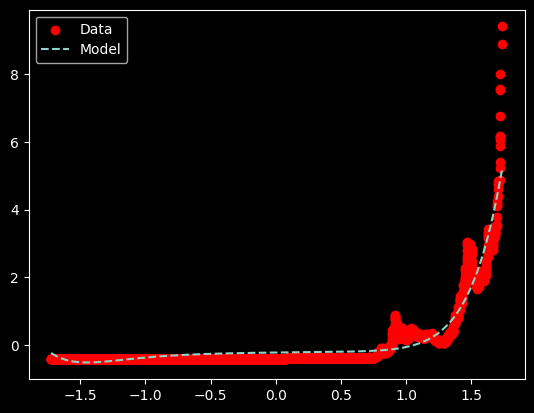

In [88]:
# Visualisation des résultats finaux
Y_pred = predict(X_poly, beta)
plt.scatter(X, Y, color='red', label="Data")
plt.plot(X, Y_pred, linestyle="--", label="Model")
plt.legend()
plt.show()